### we have 50 embeddings for both sc and st . how will the umap for combined object and embedding

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import SEACells
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad


In [2]:
sc_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad")
st_ad=sc.read_h5ad("/Users/anushka/Documents/Undergraduate-Project/obsm-anndata-file/st_data.h5ad")


In [3]:
cell_types_sc = sc_ad.obs["cell_type"].values
cell_types_st = st_ad.obs["cell_type"].values
combined_cell_types = np.concatenate((cell_types_sc, cell_types_st), axis=0)
print("Shape of combined_cell_types", combined_cell_types.shape)

Shape of combined_cell_types (25932,)


In [4]:
envi_latent_st = st_ad.obsm['envi_latent']
envi_latent_sc = sc_ad.obsm['envi_latent']

print(f"st_ad envi_latent shape: {envi_latent_st.shape}")
print(f"sc_ad envi_latent shape: {envi_latent_sc.shape}")

st_ad envi_latent shape: (18516, 512)
sc_ad envi_latent shape: (7416, 512)


## Combining both envi latent matrices for sc and st data

In [5]:
combined_envi_latent = np.concatenate([envi_latent_sc, envi_latent_st], axis=0)
print(combined_envi_latent.shape)

(25932, 512)


## Using pca to reduce the features to 50

In [6]:
from sklearn.decomposition import PCA

n_components = 50
pca = PCA(n_components=n_components)
envi_pca = pca.fit_transform(combined_envi_latent)
print("Reduced shape:", envi_pca.shape)



Reduced shape: (25932, 50)


## Combining both sc and st covet matrices


In [7]:
# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_ad.obsm["COVET_SQRT"].reshape(st_ad.shape[0], -1)
sc_covet_sqrt_flat = sc_ad.obsm["COVET_SQRT"].reshape(sc_ad.shape[0], -1)

covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)
print("Shape after flattening: ", covet_sqrt_combined.shape)

Shape after flattening:  (25932, 4096)


## Using pca on the combined covet to reduce the features to 50

In [8]:
covet_pca = pca.fit_transform(covet_sqrt_combined)
print("Reduced shape:", covet_pca.shape)

Reduced shape: (25932, 50)


## Final combined matrix with 100 features

In [9]:
combined_matrix=np.concatenate([covet_pca, envi_pca], axis=1)
print(combined_matrix.shape)

(25932, 100)


## Converting this to anndata object to obtain the umap

In [14]:
adata=ad.AnnData(X=combined_matrix)
adata.obs["cell_type"] = combined_cell_types
adata.obsm["combined_matrix"] = combined_matrix
print(adata)

AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    obsm: 'combined_matrix'


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 100 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


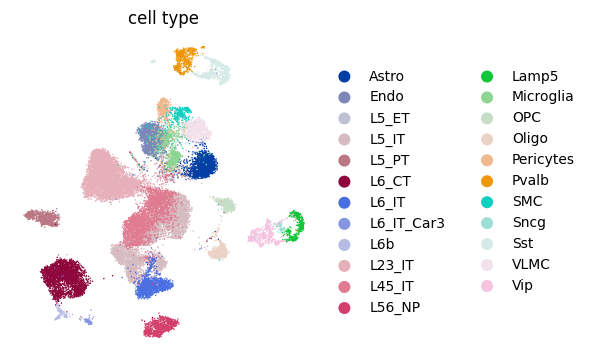

In [15]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.scatter(adata, basis='umap', color=['cell_type'], frameon=False)


## Now Using SeaCells on this 100 embedding combined data

In [16]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=False)
print(adata)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


AnnData object with n_obs × n_vars = 25932 × 100
    obs: 'cell_type'
    uns: 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'combined_matrix', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


In [17]:
n_SEACells=100 
build_kernel_on='X_pca'
n_waypoint_eigs=10

In [18]:
model= SEACells.core.SEACells(adata, 
                              build_kernel_on= build_kernel_on,
                              n_SEACells=n_SEACells,
                              n_waypoint_eigs=n_waypoint_eigs,
                              convergence_epsilon=1e-5
                              )

Welcome to SEACells!


In [19]:
model.construct_kernel_matrix()
M=model.kernel_matrix

Computing kNN graph using scanpy NN ...
Computing radius for adaptive bandwidth kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


  0%|          | 0/25932 [00:00<?, ?it/s]

Building similarity LIL matrix...


  0%|          | 0/25932 [00:00<?, ?it/s]

Constructing CSR matrix...


In [20]:
model.initialize_archetypes()

Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 95 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 15/15 [00:00<00:00, 52.62it/s]

Selecting 5 cells from greedy initialization.


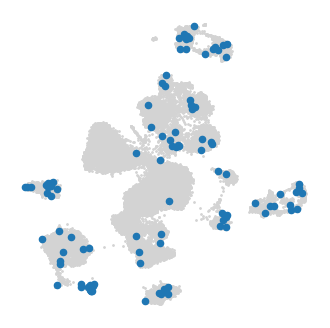

In [21]:
SEACells.plot.plot_initialization(adata, model)

In [22]:
model.fit(min_iter=10, max_iter=50)
print (f'Ran for {len(model.RSS_iters)} iterations')

Randomly initialized A matrix.
Setting convergence threshold at 0.00289
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Converged after 19 iterations.
Ran for 20 iterations


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


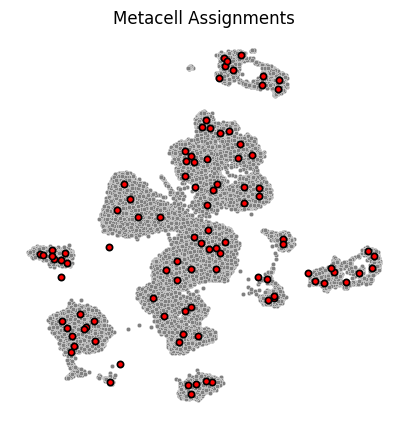

In [23]:
SEACells.plot.plot_2D(adata, colour_metacells=False)

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/SEACells/plot.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mcs = umap.groupby("SEACell").mean().reset_index()
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)
/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


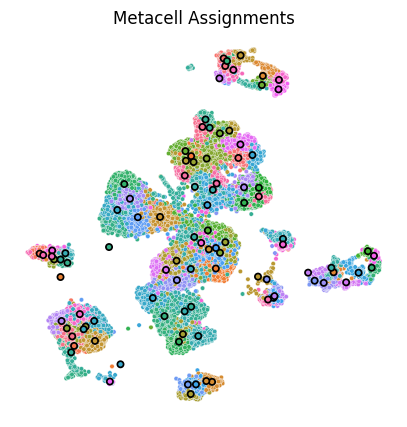

In [24]:
SEACells.plot.plot_2D(adata, colour_metacells=True)

## Now calculating separate knn graphs for both envi and covet 

In [23]:
envi_pca.shape

(25932, 50)

In [24]:
covet_pca.shape

(25932, 50)

In [25]:
adata_envi = ad.AnnData(envi_pca)
adata_covet = ad.AnnData(covet_pca)
sc.pp.neighbors(adata_envi, n_neighbors=10, use_rep="X")
sc.pp.neighbors(adata_covet, n_neighbors=10, use_rep="X")

knn_envi = adata_envi.obsp['connectivities']
knn_covet = adata_covet.obsp['connectivities']

print(knn_envi.shape, knn_covet.shape)

(25932, 25932) (25932, 25932)


### Combining these graphs using shared nearest neighbours

In [26]:
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

def compute_knn_indices(data, n_neighbors):
    n_samples = data.shape[0]
    nbrs = NearestNeighbors(n_neighbors=n_neighbors).fit(data)
    knn_indices = np.zeros((n_samples, n_neighbors), dtype=int)

    for i in tqdm(range(n_samples), desc="Computing kNN", ncols=80):
        _, indices = nbrs.kneighbors(data[i].reshape(1, -1))
        knn_indices[i] = indices[0]
        
    return knn_indices, nbrs

In [27]:
knn_indices_covet, _ = compute_knn_indices(covet_pca, n_neighbors=10)


Computing kNN: 100%|█████████████████████| 25932/25932 [00:27<00:00, 928.44it/s]


In [28]:
knn_indices_envi, _= compute_knn_indices(envi_pca, n_neighbors=10)

Computing kNN: 100%|█████████████████████| 25932/25932 [00:28<00:00, 923.16it/s]


In [29]:
print(knn_indices_envi.shape, knn_indices_covet.shape)


(25932, 10) (25932, 10)


In [30]:
from scipy.sparse import csr_matrix
def compute_snn(knn1, knn2, n_neighbors=10):
    n_samples = knn1.shape[0]
    snn = np.zeros((n_samples, n_samples), dtype=np.float32)

    for i in range(n_samples):
        neighbors_1 = set(knn1[i])
        neighbors_2 = set(knn2[i])

        # Find shared neighbors
        shared_neighbors = neighbors_1.intersection(neighbors_2)

        for j in shared_neighbors:
            rank1 = np.where(knn1[i] == j)[0][0]
            rank2 = np.where(knn2[i] == j)[0][0]
            score = n_neighbors - 0.5 * (rank1 + rank2)
            snn[i, j] = score
            snn[j, i] = score  # Ensure symmetry

    return csr_matrix(snn)

### Calculating snn matrix of the same 

In [31]:
snn_matrix = compute_snn(knn_indices_envi, knn_indices_covet, n_neighbors=10)
print("SNN Matrix Shape:", snn_matrix.shape)

SNN Matrix Shape: (25932, 25932)


### Saving the matrix

In [39]:
import numpy as np
import scipy.sparse as sp

# Assuming your SNN matrix is 'snn_matrix'
save_path = '/Users/anushka/Documents/Undergraduate-Project/Approaches/snn_matrix'

# If it's sparse, use scipy to save
if sp.issparse(snn_matrix):
    sp.save_npz(save_path, snn_matrix)
else:
    np.savez_compressed(save_path, snn_matrix=snn_matrix)

print(f"Matrix saved to {save_path}")


Matrix saved to /Users/anushka/Documents/Undergraduate-Project/Approaches/snn_matrix
